In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchattacks
import numpy as np
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve
from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001
EPSILONS = [0.0001,0.0002, 0.0003, 0.0004, 0.001, 0.002, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]  
print(f"🖥️ Device: {device}")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testloader  = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class Model_A(nn.Module):  
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 64, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool2d(2)
        )
        with torch.no_grad():
            self.feat_size = self.features(torch.zeros(1, 1, 28, 28)).numel()
        self.fc1 = nn.Linear(self.feat_size, 256)
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()
        self.feature_maps = {}

    def forward(self, x):
        x = self.features(x)
        self.feature_maps['layer2'] = x
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def train_clean(model, loader, epochs, lr):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        running_loss = 0.0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

def extract_features_and_labels(model, loader):
    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            _ = model(X)
            feats.append(model.feature_maps['layer2'].cpu().numpy().reshape(X.size(0), -1))
            labels.append(y.numpy().astype(int))
    return np.vstack(feats), np.concatenate(labels)

class MahalanobisDetector:
    def __init__(self, reg_cov=1e-4):
        self.class_means = {}
        self.inv_covs = {}
        self.reg = reg_cov
    def fit(self, X, y, num_classes=10):
        for c in range(num_classes):
            mask = y == c
            feats = X[mask]
            if len(feats) == 0: continue
            self.class_means[c] = feats.mean(axis=0)
            cov = np.cov(feats, rowvar=False)
            cov += self.reg * np.eye(cov.shape[0])
            self.inv_covs[c] = inv(cov)
        return self
    def score(self, X, y):
        scores = []
        for i in range(len(y)):
            c = int(y[i])
            if c not in self.class_means:
                scores.append(1e6); continue
            diff = X[i] - self.class_means[c]
            d = mahalanobis(diff, np.zeros_like(diff), self.inv_covs[c])
            scores.append(d**2 if np.isfinite(d) else 1e6)
        return np.array(scores)

def tpr_at_fpr(y_true, y_scores, fpr_target):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    return np.interp(fpr_target, fpr, tpr)

if __name__ == "__main__":
    configs = [
        ("Model_A", Model_A, MahalanobisDetector()),
    ]

    print(f"\n🚀 Оценка обнаруживаемости (атака: BIM, шаги=10, alpha=eps/4)")
    print(f"{'Модель':<10} | {'Детектор':<15} | {'ε':<5} | {'TPR@FPR=1 %':<12}")
    print("-" * 55)

    for model_name, model_cls, detector in configs:
        print(f"  [Обучение] {model_name}...")
        model = model_cls().to(device)
        train_clean(model, trainloader, EPOCHS, LR)

        X_clean, y_clean = extract_features_and_labels(model, testloader)

        if isinstance(detector, MahalanobisDetector):
            detector.fit(X_clean, y_clean)
            scores_clean = detector.score(X_clean, y_clean)
        else:
            detector.fit(X_clean)
            scores_clean = detector.score(X_clean)

        for eps in EPSILONS:
            model.eval()
            X_adv_list, y_adv_list = [], []
            atk = torchattacks.BIM(model, eps=eps, steps=10, alpha=eps/4)
            
            for X, y in testloader:
                X, y = X.to(device), y.to(device)
                X_adv = atk(X, y)  # Требует вычисления градиентов
                with torch.no_grad():
                    _ = model(X_adv)
                    f = model.feature_maps['layer2'].cpu().numpy().reshape(X_adv.size(0), -1)
                X_adv_list.append(f)
                y_adv_list.append(y.cpu().numpy().astype(int))
                
            X_adv = np.vstack(X_adv_list)
            y_adv = np.concatenate(y_adv_list)

            if isinstance(detector, MahalanobisDetector):
                scores_adv = detector.score(X_adv, y_adv)
            else:
                scores_adv = detector.score(X_adv)

            sc_c = scores_clean.copy()
            sc_a = scores_adv.copy()
            if np.mean(sc_c) > np.mean(sc_a):
                sc_c = -sc_c
                sc_a = -sc_a

            y_true = np.concatenate([np.zeros(len(sc_c)), np.ones(len(sc_a))])
            y_scores = np.concatenate([sc_c, sc_a])

            tpr1 = tpr_at_fpr(y_true, y_scores, 0.01)
            print(f"{model_name:<10} | {detector.__class__.__name__:<15} | {eps:<5.2f} | {tpr1:<12.3f}")

🖥️ Device: cpu

🚀 Оценка обнаруживаемости (атака: BIM, шаги=10, alpha=eps/4)
Модель     | Детектор        | ε     | TPR@FPR=1 % 
-------------------------------------------------------
  [Обучение] Model_A...
Model_A    | MahalanobisDetector | 0.00  | 0.010       
Model_A    | MahalanobisDetector | 0.00  | 0.016       
Model_A    | MahalanobisDetector | 0.00  | 0.034       
Model_A    | MahalanobisDetector | 0.00  | 0.070       
Model_A    | MahalanobisDetector | 0.00  | 0.417       
Model_A    | MahalanobisDetector | 0.00  | 0.768       
Model_A    | MahalanobisDetector | 0.01  | 0.935       
Model_A    | MahalanobisDetector | 0.01  | 0.999       
Model_A    | MahalanobisDetector | 0.05  | 1.000       
Model_A    | MahalanobisDetector | 0.10  | 1.000       
Model_A    | MahalanobisDetector | 0.15  | 1.000       
Model_A    | MahalanobisDetector | 0.20  | 1.000       
Model_A    | MahalanobisDetector | 0.30  | 1.000       
Model_A    | MahalanobisDetector | 0.40  | 1.000       


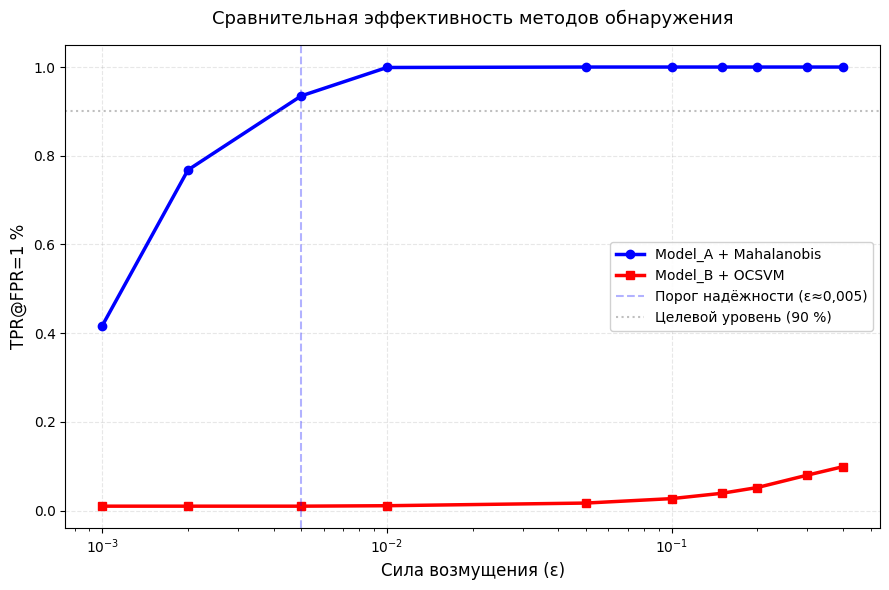

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Данные из эксперимента
epsilons = [0.001, 0.002, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
tpr_maha = [0.417, 0.768, 0.935, 0.999, 1.000, 1.000, 1.000, 1.000, 1.000, 1.000]
tpr_ocsvm = [0.010, 0.010, 0.010, 0.011, 0.017, 0.027, 0.039, 0.052, 0.080, 0.099]

plt.figure(figsize=(9, 6))
plt.plot(epsilons, tpr_maha, 'b-o', linewidth=2.5, markersize=6, label='Model_A + Mahalanobis')
plt.plot(epsilons, tpr_ocsvm, 'r-s', linewidth=2.5, markersize=6, label='Model_B + OCSVM')

plt.axvline(x=0.005, color='b', linestyle='--', alpha=0.3, label='Порог надёжности (ε≈0,005)')
plt.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5, label='Целевой уровень (90 %)')

plt.xlabel('Сила возмущения (ε)', fontsize=12)
plt.ylabel('TPR@FPR=1 %', fontsize=12)
plt.title('Сравнительная эффективность методов обнаружения', fontsize=13, pad=15)
plt.xscale('log')
plt.grid(alpha=0.3, linestyle='--', axis='both')
plt.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig('comparison_detection_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchattacks
import numpy as np
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001
EPSILONS = [0.0001, 0.0002, 0.0003, 0.0004, 0.001, 0.002, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
print(f"🖥️ Device: {device}")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testloader  = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class Model_B(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        with torch.no_grad():
            self.feat_size = self.features(torch.zeros(1, 1, 28, 28)).numel()
        self.fc1 = nn.Linear(self.feat_size, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.feature_maps = {}

    def forward(self, x):
        x = self.features(x)
        self.feature_maps['layer2'] = x
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def train_clean(model, loader, epochs, lr):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        running_loss = 0.0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

def extract_features_and_labels(model, loader):
    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            _ = model(X)
            feats.append(model.feature_maps['layer2'].cpu().numpy().reshape(X.size(0), -1))
            labels.append(y.numpy().astype(int))
    return np.vstack(feats), np.concatenate(labels)

class OCSVMDetector:
    def __init__(self, nu=0.01):
        self.clf = OneClassSVM(nu=nu, gamma='scale')
    def fit(self, X):
        self.clf.fit(X)
        return self
    def score(self, X):
       
        return -self.clf.decision_function(X)

def tpr_at_fpr(y_true, y_scores, fpr_target):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    return np.interp(fpr_target, fpr, tpr)

if __name__ == "__main__":

    configs = [
        ("Model_B", Model_B, OCSVMDetector())
    ]

    print(f"\n🚀 Оценка обнаруживаемости (атака: BIM, шаги=10, alpha=eps/4)")
    print(f"{'Модель':<10} | {'Детектор':<15} | {'ε':<5} | {'TPR@FPR=1 %':<12}")
    print("-" * 55)

    for model_name, model_cls, detector in configs:
        print(f"  [Обучение] {model_name}...")
        model = model_cls().to(device)
        train_clean(model, trainloader, EPOCHS, LR)

        X_clean, y_clean = extract_features_and_labels(model, testloader)

        detector.fit(X_clean)
        scores_clean = detector.score(X_clean)

        for eps in EPSILONS:
            model.eval()
            X_adv_list, y_adv_list = [], []
            atk = torchattacks.BIM(model, eps=eps, steps=10, alpha=eps/4)
            
            for X, y in testloader:
                X, y = X.to(device), y.to(device)
                X_adv = atk(X, y)
                with torch.no_grad():
                    _ = model(X_adv)
                    f = model.feature_maps['layer2'].cpu().numpy().reshape(X_adv.size(0), -1)
                X_adv_list.append(f)
                y_adv_list.append(y.cpu().numpy().astype(int))
                
            X_adv = np.vstack(X_adv_list)
            y_adv = np.concatenate(y_adv_list)

            scores_adv = detector.score(X_adv)

            sc_c = scores_clean.copy()
            sc_a = scores_adv.copy()
            if np.mean(sc_c) > np.mean(sc_a):
                sc_c = -sc_c
                sc_a = -sc_a

            y_true = np.concatenate([np.zeros(len(sc_c)), np.ones(len(sc_a))])
            y_scores = np.concatenate([sc_c, sc_a])

            tpr1 = tpr_at_fpr(y_true, y_scores, 0.01)
            print(f"{model_name:<10} | {detector.__class__.__name__:<15} | {eps:<5.2f} | {tpr1:<12.3f}")

🖥️ Device: cpu

🚀 Оценка обнаруживаемости (атака: BIM, шаги=10, alpha=eps/4)
Модель     | Детектор        | ε     | TPR@FPR=1 % 
-------------------------------------------------------
  [Обучение] Model_B...
Model_B    | OCSVMDetector   | 0.00  | 0.010       
Model_B    | OCSVMDetector   | 0.00  | 0.010       
Model_B    | OCSVMDetector   | 0.00  | 0.010       
Model_B    | OCSVMDetector   | 0.00  | 0.010       
Model_B    | OCSVMDetector   | 0.00  | 0.010       
Model_B    | OCSVMDetector   | 0.00  | 0.011       
Model_B    | OCSVMDetector   | 0.01  | 0.011       
Model_B    | OCSVMDetector   | 0.01  | 0.011       
Model_B    | OCSVMDetector   | 0.05  | 0.017       
Model_B    | OCSVMDetector   | 0.10  | 0.029       
Model_B    | OCSVMDetector   | 0.15  | 0.041       
Model_B    | OCSVMDetector   | 0.20  | 0.056       
Model_B    | OCSVMDetector   | 0.30  | 0.083       
Model_B    | OCSVMDetector   | 0.40  | 0.098       
